## start generating questions

In [1]:
import sys
def return_prompt(sample):
    sys.path.insert(0, "/home/srini/time_series")
    from loopqa.eval import LoopQAEvaluator


    txt = LoopQAEvaluator.format_patient_context(sample['input_context'])
    qa_item = sample['qa_pairs'][0]
    prompt = LoopQAEvaluator.create_prompt(txt, qa_item['question_text'], qa_item['answer_instruction'], qa_item['answer_type'], example_answer=qa_item['example_answer'])
    return prompt

#### 1. At what time of day does my highest glucose usually occur 

In [ ]:
import numpy as np
import json
import pandas as pd
import random
def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str


df = pd.read_csv("insulin_input_normal.csv")

df = df.T

i = 0

print(df.shape)
sample_patient = random.randint(0,20)
with open("./questions/questions_and_answers_0.jsonl", "w") as h:
#loop over all 20 patients
    for i in range(0, 20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"


        #count for each time period for each patient
        dic = {
        "morning": 0,
        "afternoon": 0, 
        "evening": 0,
        "night": 0
        }

        with open(file_path, "r") as f:
            data = json.load(f)

        insulin_lis = []
        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        output_json['input_context']['running_events'] = []
        output_json['input_context']['cycling_events'] = []
        output_json['input_context']['insulin_events'] = df[i].to_list()
        output_json['input_context']['carb_events'] = data['carb_events']
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl']
        output_json['qa_pairs'] = []
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'get_bg_values'
        qa['question_id'] = 'pm_0'
        qa['question_text'] = 'Predict during what time of the day will my blood glucose level be highest?'
        qa['answer_generation_rule'] = "The answer should be morning, afternoon, evening or night where morning is from 6AM to 12PM, afternoon is from 12PM to 6PM, evening is from 6PM to 12AM and night is from 12AM to 6AM"
        qa['answer_instruction'] = "Use the sampled blood glucose values to predict the time of the day when the blood glucose level will be highest for each day and then return the most common time period based on the count of each time period"
        qa['answer_type'] = "string"
        qa['metric'] = 'accuracy'
        qa['answer_instruction'] = qa['answer_generation_rule']
        
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                output_json['input_context']['running_events'].append(ex)
            elif ex['exercise_type'] == 'cycling':
                output_json['input_context']['cycling_events'].append(ex)

        bg_values = data['bg_mgdl']
        bg_values_per_day = np.array_split(bg_values, 30)

        # Find the time of the day when the bg_values are highest for each day
        
        for day, day_data in enumerate(bg_values_per_day):
            max_mins = np.argmax(day_data)
            max_time_of_day = ( max_mins * 5 )
            if 360 <= max_time_of_day < 720:
                period = "Morning"
            elif 720 <= max_time_of_day < 1080:
                period = "Afternoon"
            elif 1080 <= max_time_of_day < 1440:
                period = "Evening"
            else:
                period = "Night"
            
            if period == "Morning":
                dic["morning"] += 1
            elif period == "Afternoon":
                dic["afternoon"] += 1
            elif period == "Evening":
                dic["evening"] += 1
            else:
                dic["night"] += 1

            #print(f"Day {day+1}: Highest BG at {format_time_info(max_mins * 5)[1]} ({period})")


        # Find the most common time period
        most_common_period = max(dic, key=dic.get)
        print("For Patient", i , "max glucoser occurs in" , most_common_period)
        
        example_answer = ""
        for key in dic.keys():
            if key != most_common_period:
                example_answer = key
                break
        

        
        assert most_common_period != example_answer, "most_common_period and example_answer are the same"
        qa['answer'] = most_common_period
        qa['example_answer'] = example_answer
        output_json['qa_pairs'].append(qa)

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/0.txt", "w") as f:
                f.write(prompt)
                
        h.write(json.dumps(output_json) + "\n")


(8640, 20)
For Patient 0 max glucoser occurs in morning
sample patient 0
For Patient 1 max glucoser occurs in afternoon
For Patient 2 max glucoser occurs in afternoon
For Patient 3 max glucoser occurs in morning
For Patient 4 max glucoser occurs in evening
For Patient 5 max glucoser occurs in afternoon
For Patient 6 max glucoser occurs in morning
For Patient 7 max glucoser occurs in morning
For Patient 8 max glucoser occurs in morning
For Patient 9 max glucoser occurs in morning
For Patient 10 max glucoser occurs in afternoon
For Patient 11 max glucoser occurs in morning
For Patient 12 max glucoser occurs in morning
For Patient 13 max glucoser occurs in morning
For Patient 14 max glucoser occurs in morning
For Patient 15 max glucoser occurs in morning
For Patient 16 max glucoser occurs in afternoon
For Patient 17 max glucoser occurs in morning
For Patient 18 max glucoser occurs in morning
For Patient 19 max glucoser occurs in morning


## 2. where will my blood sugar be in the next 30 minutes. 

In [3]:
# transpose the dataframe
import pandas as pd
import json
import random


def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str


df = pd.read_csv("insulin_input_normal.csv")

df = df.T

i = 0

sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_1.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        # Each bg_time step is 5 minutes, so 30 minutes later is +6 indices
        if len(bg_time) > 6:
            cut_idx = random.randint(15, len(bg_time) - 7)
            
            
            cut_bg = bg_values[cut_idx]
            future_idx = cut_idx + 6
            cut_time = bg_time[cut_idx]
            future_time = bg_time[future_idx]
            future_bg = bg_values[future_idx]

            for ex in data['exercise_events']:
                if ex['exercise_type'] == 'running':
                    if ex['time'] <= cut_time: 
                        running_events.append(ex)
                elif ex['exercise_type'] == 'cycling':
                    if ex['time'] <= cut_time: 
                        cycling_events.append(ex)

            for carb in data['carb_events']:
                if carb['time'] <= cut_time:
                    carb_events.append(carb)
        
            qa = {}
            qa['patient_id'] = 'Patient_'+str(i)
            qa['function_name'] = 'get_future_bg_values'
            qa['question_id'] = 'pm_1'
            qa['question_text'] = 'Predict what my blood glucose level will be in 30 minutes?'
            qa['answer_generation_rule'] = "Use the relevant information given and predict a valid blood glucose value"
            qa['answer_instruction'] = "Use the given blood glucose values, insulin values, exercise events and carb events to predict the blood glucose level in 30 minutes"
            qa['answer_type'] = "float"
            qa['metric'] = 'MAE'

            val = random.randint(15,45)
            qa['example_answer'] = future_bg - ((val / 100) * future_bg)
            qa['answer'] = future_bg    
            qa['answer_instruction'] = qa['answer_generation_rule']
        
            output_json['input_context']['running_events'] = running_events
            output_json['input_context']['cycling_events'] = cycling_events
            output_json['input_context']['carb_events'] = carb_events
            output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx+1]
            output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx+1]
            output_json['qa_pairs'] = []
            output_json['qa_pairs'].append(qa)

            #checks to ensure the cut index is correct
            assert output_json['input_context']['bg_mgdl'][-1] == cut_bg
            assert len(output_json['input_context']['insulin_events']) == len(output_json['input_context']['bg_mgdl']) == cut_idx+1
            assert carb_events[-1]['time'] <= cut_time
            assert running_events[-1]['time'] <= cut_time
            assert cycling_events[-1]['time'] <= cut_time
            assert example_answer != qa['answer']

            if i == sample_patient:
                print("sample patient", i)
                prompt = return_prompt(output_json)
                with open("./prompts/prediction/1.txt", "w") as f:
                    f.write(prompt)
        else:
            print("Not enough data to sample 30 minutes ahead.")

        h.write(json.dumps(output_json) + "\n")



sample patient 13


In [4]:
prompt = return_prompt(output_json)
print(output_json['qa_pairs'][0]['answer'])
with open("./prompts/prediction/1.txt", "w") as f:
    f.write(prompt)
print(prompt)

127.7705745122025
You are a medical AI assistant analyzing diabetes management data. Based on the patient's health data, answer the following question accurately.

PATIENT DATA OVERVIEW:
This data represents a continuous glucose monitoring (CGM) session for a diabetes patient. The data includes:
- Blood glucose readings taken every 5 minutes, begining at Week 1, Day 1, 00:00 (normal range: 70-180 mg/dL)
- Carbohydrate intake events with timing and amounts
- Insulin delivery events (basal background insulin and bolus meal insulin)
- Physical activity events (running/cycling with duration and intensity)

The data may contain various artifacts, sensor issues, or abnormal patterns that need to be identified and analyzed.

Patient Health Data:

Blood Glucose Readings (mg/dL, every 5 minutes): 5927 readings
  Values: 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.1, 108.1, 108.2, 108.3, 108.4, 108.6, 108.8, 109.0, 109.2, 109.5, 109.7, 109.9, 110.0, 110.2, 110.3, 110.4, 110.4, 110.5, 11

### 3. How much insulin will i use on monday next week.

In [5]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str


df = pd.read_csv("insulin_input_normal.csv")

df = df.T

i = 0
sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_2.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        insulin_lis = df[i].to_list()
        insulin_split = np.array_split(insulin_lis, 30)

        assert np.array_equal(insulin_split[14], insulin_lis[14 * 288:15 * 288]) == True 
        # take the first 21 days of insulin values
        average_3_weeks = (sum(insulin_split[0]) + sum(insulin_split[7]) + sum(insulin_split[14])) / 3
        cut_idx = (15 * 288)
        cut_bg = data['bg_mgdl'][cut_idx-1]
        cut_time = bg_time[cut_idx]

        
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)
        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'get_next_week_values'
        qa['question_id'] = 'pm_2'
        qa['question_text'] = 'How much insulin will I consume next monday?'
        qa['answer_generation_rule'] = "Use the insulin consumed on the 1st, 8th and 15th of the month to predict the total insulin consumption for monday next week."
        qa['answer_instruction'] = "Return the total insulin consumption for monday next week as a float value"
        qa['answer_type'] = "float"
        qa['metric'] = 'MAE'

        val = random.randint(15,45)
        qa['example_answer'] = average_3_weeks - ((val / 100) * average_3_weeks)
        qa['answer'] = average_3_weeks    
        qa['answer_instruction'] = qa['answer_generation_rule']
        
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)
        
        assert output_json['input_context']['bg_mgdl'][-1] == cut_bg, "glucose value at cut_idx is not equal to cut_bg"
        assert len(output_json['input_context']['insulin_events']) == len(output_json['input_context']['bg_mgdl']) == cut_idx, "length of insulin_events and bg_mgdl is not equal to cut_idx+1"
        assert carb_events[-1]['time'] < cut_time, "carb event time is greater than cut_time"
        assert running_events[-1]['time'] < cut_time, "running event time is greater than cut_time"
        assert cycling_events[-1]['time'] < cut_time, "cycling event time is greater than cut_time"
        assert insulin_split[14][-1] == df[i].to_list()[:cut_idx][-1]
        assert example_answer != qa['answer']

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/2.txt", "w") as f:
                f.write(prompt)
        h.write(json.dumps(output_json) + "\n")


sample patient 19


##### 4. Will late-night snacks push my sugar to higher limits. (>=180)

In [6]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np
import sys


def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_late_night_snack.csv")

df = df.T

i = 0
temp_lis = []
sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_3.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/late_night_snack/late_night_snack_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 21 * 288    
        cut_time = bg_time[cut_idx]
        offset = 0
        for carb in data['carb_events']:
            if carb['time'] >= cut_time - 120 and carb['time'] < cut_time:
                snack_time = (carb['time']//5) + 1 #simulate 5 minutes into the snack for adding snack event

        cut_idx = int(snack_time)
        end_idx = int(snack_time) + 60 # 60 is the number of 5 minute intervals in 5 hour
        cut_time = bg_time[cut_idx]
        bg_spike = bg_values[cut_idx:end_idx+1]
        count=0
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                if carb['meal_type'] == 'afternoon_snack' or carb['meal_type'] == 'morning_snack':
                    carb['meal_type'] = 'snack'
                carb_events.append(carb)
        ans = "No"
        if max(bg_spike) > 180:
            ans = "Yes"

        qa = {}
        qa['patient_id'] = 'Patient_'+ str(i)
        qa['function_name'] = 'get_spike_late_night'
        qa['question_id'] = 'pm_3'
        qa['question_text'] = 'Will having a late night snack now push my sugar to higher limits (>180mg/dL)?'
        qa['answer_generation_rule'] = "Consider 5 hours post snack time for checking if the sugar will be higher than 180mg/dL at any point. If you think the sugar will be higher than 180mg/dL, answer 'Yes', otherwise answer 'No'"
        qa['answer_instruction'] = "If you think the sugar will be higher than 180mg/dL, answer 'Yes', otherwise answer 'No'"
        qa['answer_type'] = "string"
        qa['metric'] =  'accuracy'
        qa['example_answer'] = "Yes" if ans == 'No' else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert example_answer != qa['answer']

        temp_lis.append(output_json)

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/3.txt", "w") as f:
                f.write(prompt)
        h.write(json.dumps(output_json) + "\n")

sample patient 5


##### 5. How much of tomorrow will I stay in range (70-180) assuming i take my insulin correctly?

In [7]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str


df = pd.read_csv("insulin_input_normal.csv")

df = df.T

i = 0

sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_4.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        cut_idx = 14 * 288    
        next_day_idx = cut_idx + 288
        cut_time = bg_time[cut_idx]
        bg_values_next_day = bg_values[cut_idx:next_day_idx]
        
        count=0
        for bg_val in bg_values_next_day:
            if bg_val >=70 and bg_val <= 180:
                count +=1
        
        print((count / len(bg_values_next_day)) * 100) 

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)
        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'get_next_day_normal_values'
        qa['question_id'] = 'pm_4'
        qa['question_text'] = 'what percentage of the day tomorrow will I stay in range (70-180) assuming i take my insulin correctly?'
        qa['answer_generation_rule'] = "Make a prediction based on the carb intake, insulin, blood glucose values and exercise events"
        qa['answer_instruction'] = "Return the percentage of the day I will stay in range (70-180) tomorrow as a float value"
        qa['answer_type'] = "float"
        qa['metric'] = 'MAE'

        ans = (count / len(bg_values_next_day)) * 100
        qa['example_answer'] = ans - ((random.randint(1,50) / 100) * ans)
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert len(output_json['input_context']['insulin_events']) == len(output_json['input_context']['bg_mgdl'])
        assert qa['example_answer'] != qa['answer']
        
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/4.txt", "w") as f:
                f.write(prompt)
                
        h.write(json.dumps(output_json) + "\n")

35.41666666666667
95.48611111111111
44.44444444444444
63.19444444444444
sample patient 3
93.05555555555556
90.97222222222221
98.26388888888889
56.59722222222222
63.541666666666664
100.0
55.55555555555556
64.93055555555556
65.27777777777779
69.79166666666666
100.0
70.83333333333334
23.61111111111111
53.81944444444444
95.13888888888889
82.63888888888889


#### 6. Will my running excersice cause me to become hypoglycemic if i start training now where I will run for 30 minutes? 

In [8]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_5.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 10 * 288 + 84
        cut_time = bg_time[cut_idx]
        for running in data['exercise_events']:
            if running['exercise_type'] == 'running':
                if running['time'] >= cut_time - 120 and running['time'] <= cut_time:
                    running_time = (running['time']//5)
                                
        
        
        
        cut_idx = int(running_time)
        end_idx = int(running_time) + 18 #90 minutes after running starts
        cut_time = bg_time[cut_idx]
        #print("cut_time", format_time_info(cut_time), format_time_info(bg_time[end_idx]))
        bg_spike = bg_values[cut_idx:end_idx+1]
        count=0

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)

        ans = "No"

        if min(bg_spike) < 70:
            ans = "Yes"

        print(ans)
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_hypoglycemia'
        qa['question_id'] = 'pm_5'
        qa['question_text'] = 'Will my running exercise cause me to become hypoglycemic in the next 90 minutes if i start training now where I will run for 30 minutes?'
        qa['answer_generation_rule'] = "Take the current blood glucose values and assume the running exercise event immediately starts and predict if the blood glucose values will be lower than 70mg/dL in the next 90 minutes.If you think the blood glucose values will be lower than 70mg/dL, answer 'Yes', otherwise answer 'No'"
        qa['answer_instruction'] = "If you think the blood glucose values will be lower than 70mg/dL, answer 'Yes', otherwise answer 'No'"
        qa['answer_type'] = "string"
        qa['metric'] =  'accuracy'
        qa['example_answer'] = "Yes" if ans == 'No' else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/5.txt", "w") as f:
                f.write(prompt)

        assert qa['example_answer'] != qa['answer']
        h.write(json.dumps(output_json) + "\n")

Yes
Yes
No
No
Yes
Yes
Yes
Yes
No
sample patient 8
Yes
No
No
Yes
Yes
No
Yes
No
No
No
No


#### 7. What will the glucose level be 1 hour after my breakfast? ( assume i am going to have my breakfast right away)

In [9]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_6.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 10 * 288 + 72
        end_idx = 10 * 288 + 96 
        bg_spike = bg_values[cut_idx:end_idx+1]
        #print("bg_spike", bg_spike)
        cut_time = bg_time[cut_idx]

        for carb in data['carb_events']:
            if carb['time'] >= cut_time and carb['time'] <= bg_time[end_idx]:
                carb_time = (carb['time']//5)
                if carb_time * 5 > carb['time']:
                    carb_time = carb_time -1 

                #print(format_time_info(carb['time']), format_time_info(carb_time*5))
        #print("running time", running_time)
        cut_idx = int(carb_time)
        end_idx = int(carb_time) + 12
        cut_time = bg_time[cut_idx]
        
        # print("end time", format_time_info(bg_time[end_idx]))
        # print("*" * 100)
        
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] < int(cut_time):
                carb_events.append(carb)
        
        print(carb_events[-1])
        ans = bg_values[end_idx]
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_hypoglycemia'
        qa['question_id'] = 'pm_6'
        qa['question_text'] = 'What will the glucose level be 1 hour after my breakfast? (Assume I am going to eat my breakfast right away)'
        qa['answer_generation_rule'] = "Take the current blood glucose values and assume the carbohydrate intake event immediately starts and predict the glucose level 1 hour after the carbohydrate intake. Return a float number for the glucose level 1 hour after the carbohydrate intake."
        qa['answer_instruction'] = "Return a float number for the glucose level 1 hour after the carbohydrate intake."
        qa['answer_type'] = "float"
        qa['metric'] =  'MAE'
        qa['example_answer'] = ans - ((random.randint(1,50) / 100) * ans)
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx+1]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx+1]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != qa['answer']
        if i == sample_patient:
            print("sample patient", i)
            
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/6.txt", "w") as f:
                f.write(prompt)

        h.write(json.dumps(output_json) + "\n")

{'time': 14056.969696969696, 'day': 10, 'time_str': '18:16', 'carbs': 111.91919191919192, 'meal_type': 'dinner'}
{'time': 14158.787878787878, 'day': 10, 'time_str': '19:58', 'carbs': 95.75757575757575, 'meal_type': 'dinner'}
{'time': 14100.60606060606, 'day': 10, 'time_str': '19:00', 'carbs': 99.79797979797979, 'meal_type': 'dinner'}
{'time': 14144.242424242424, 'day': 10, 'time_str': '19:44', 'carbs': 110.3030303030303, 'meal_type': 'dinner'}
{'time': 14077.575757575758, 'day': 10, 'time_str': '18:37', 'carbs': 113.53535353535354, 'meal_type': 'dinner'}
{'time': 14123.636363636364, 'day': 10, 'time_str': '19:23', 'carbs': 105.45454545454545, 'meal_type': 'dinner'}
{'time': 14047.272727272728, 'day': 10, 'time_str': '18:07', 'carbs': 111.91919191919192, 'meal_type': 'dinner'}
{'time': 14103.030303030304, 'day': 10, 'time_str': '19:03', 'carbs': 109.4949494949495, 'meal_type': 'dinner'}
{'time': 14136.969696969696, 'day': 10, 'time_str': '19:36', 'carbs': 89.6969696969697, 'meal_type': 

#### Does my insulin-to-carb ratio need adjustment this week?
#### What’s the expected glucose change 1 hour after a run or cycling session?
#### Does exercise at a particular time (morning vs evening) result in better glucose control?

#### 8. What’s the expected glucose change 15 minutes after a morning run session?

In [10]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_7.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 15 * 288 + 84
        cut_time = bg_time[cut_idx]
        for running in data['exercise_events']:
            if running['exercise_type'] == 'running':
                if running['time'] >= cut_time - 120 and running['time'] <= cut_time:
                    running_time = (running['time']//5)
                    #if running_time * 5 < running['time']:
                    #    running_time = running_time + 1
                    #print(format_time_info(running['time']), format_time_info(running_time * 5))

        cut_idx = int(running_time)
        end_idx = int(running_time) + 9 #45 minutes after running starts
        
        cut_time = bg_time[cut_idx]
        bg_diff = bg_values[end_idx] - bg_values[cut_idx]
        count=0
        
        
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] <= cut_time:
                carb_events.append(carb)
    
        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_change_in_glucose'
        qa['question_id'] = 'pm_7'
        qa['question_text'] = 'What’s the expected glucose change 15 minutes after a morning run session?'
        qa['answer_generation_rule'] = "Assume the running exercise event immediately starts and the running duration is 30 minutes. Predict the change in blood glucose values in the next 15 minutes after the run is completed. Return the change in blood glucose value as a float value"
        qa['answer_instruction'] = "Return the change in blood glucose value as a float value"
        qa['answer_type'] = "float"
        qa['metric'] =  'MAE'
        qa['example_answer'] = bg_diff - ((random.randint(1,50) / 100) * bg_diff)
        qa['answer'] = bg_diff
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx+1]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx+1]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        print(qa['answer'])
        assert qa['example_answer'] != qa['answer']
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/7.txt", "w") as f:
                f.write(prompt)

        h.write(json.dumps(output_json) + "\n")

-20.491734460420187
-1.6063486299537857
-2.485974860868115
27.64108851152693
-30.868538044756043
-2.63133297951471
-46.91203406582245
-70.44817910063713
-10.13319140601432
-6.432996187805799
-23.79063264091927
0.6340141145087301
102.94709662689115
38.56876724847096
sample patient 13
-11.314225302665704
-68.01235104231101
-0.666832856472432
23.608288995505347
-0.04583007860547639
-5.681845041263188


In [11]:
prompt = return_prompt(output_json)
print(prompt)

You are a medical AI assistant analyzing diabetes management data. Based on the patient's health data, answer the following question accurately.

PATIENT DATA OVERVIEW:
This data represents a continuous glucose monitoring (CGM) session for a diabetes patient. The data includes:
- Blood glucose readings taken every 5 minutes, begining at Week 1, Day 1, 00:00 (normal range: 70-180 mg/dL)
- Carbohydrate intake events with timing and amounts
- Insulin delivery events (basal background insulin and bolus meal insulin)
- Physical activity events (running/cycling with duration and intensity)

The data may contain various artifacts, sensor issues, or abnormal patterns that need to be identified and analyzed.

Patient Health Data:

Blood Glucose Readings (mg/dL, every 5 minutes): 4397 readings
  Values: 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.1, 108.1, 108.2, 108.3, 108.4, 108.6, 108.8, 109.0, 109.2, 109.5, 109.7, 109.9, 110.0, 110.2, 110.3, 110.4, 110.4, 110.5, 110.5, 110.5, 110.5,

#### 9. What’s the expected glucose change 1 hour after a evening cycling session?


In [12]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_8.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 15 * 288 + 216
        cut_time = bg_time[cut_idx]
        for cycling in data['exercise_events']:
            if cycling['exercise_type'] == 'cycling':
                if cycling['time'] >= cut_time - 120 and cycling['time'] <= cut_time:
                    cycling_time = (cycling['time']//5)
                    #if cycling_time * 5 >= cycling['time']:
                    #    cycling_time = cycling_time - 1
                    #print(format_time_info(cycling['time']), format_time_info(cycling_time * 5))
        #print("running time", running_time)

        cut_idx = int(cycling_time)
        #print("cutting time", format_time_info(bg_time[cut_idx]))
        end_idx = int(cycling_time) +  16   #cycle for 20 mins and then 1 hour after that check for glucose therefore 
        cut_time = bg_time[cut_idx]

        bg_diff = bg_values[end_idx] - bg_values[cut_idx]
        #print("bg_diff", bg_diff)
        
        count=0
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] <= cut_time:
                carb_events.append(carb)

        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_change_in_glucose'
        qa['question_id'] = 'pm_8'
        qa['question_text'] = 'What’s the expected glucose change 1 hour after a evening cycling session?'
        qa['answer_generation_rule'] = "Assume the cycling exercise event starts immedietly and the cycling duration is 20 minutes. Predict the change in blood glucose values in the next 60 minutes after the cycling session."
        qa['answer_instruction'] = "Return the change in blood glucose values in the next 60 minutes as a float value"
        qa['answer_type'] = "float"
        qa['metric'] =  'MAE'
        qa['example_answer'] = bg_diff - ((random.randint(1,50) / 100) * bg_diff)
        qa['answer'] = bg_diff
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx+1]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx+1]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)
        print(bg_diff)
        
        assert qa['example_answer'] != qa['answer']
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/8.txt", "w") as f:
                f.write(prompt)

        h.write(json.dumps(output_json) + "\n")

-80.54702484073518
16.604718518186644
-17.337627373493845
-19.913956733092704
-7.648641202400867
0.7850752376943788
-11.028820238151738
-31.231909572734324
-34.75606188451961
-49.694873092382494
-35.096844857745396
sample patient 10
-28.562541303633708
-35.39836796401271
-49.107011047446605
-17.45066907717741
-46.23736601019655
-17.47277776300563
-51.355431862663025
-38.636089655022246
-47.047307773256776


### 10. Which excercise is better for me to bring down blood sugar tomorrow - cycling or running?

In [13]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def calc(bg_diff_cycling, bg_diff_running):
    if bg_diff_cycling > 0 and bg_diff_running > 0:
        return "cycling" if bg_diff_cycling < bg_diff_running else "running"
    elif bg_diff_cycling > 0 and bg_diff_running < 0:
        return "running"
    elif bg_diff_cycling < 0 and bg_diff_running > 0:
        return "cycling"
    else:
        return "cycling" if bg_diff_cycling < bg_diff_running else "running"

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_9.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        main_idx = 15 * 288
        main_time = bg_time[main_idx]
        

        cut_idx_cycling = 15 * 288 + 216
        cut_time_cycling = bg_time[cut_idx_cycling]
        
        cut_idx_running = 15 * 288 + 84
        cut_time_running = bg_time[cut_idx_running]
        
        
        for cycling in data['exercise_events']:
            if cycling['exercise_type'] == 'cycling':
                if cycling['time'] >= cut_time_cycling - 120 and cycling['time'] <= cut_time_cycling:
                    cycling_time = (cycling['time']//5) + 1

        for running in data['exercise_events']:
            if running['exercise_type'] == 'running':
                if running['time'] >= cut_time_running - 120 and running['time'] <= cut_time_running:
                    running_time = (running['time']//5) + 1

        cut_idx_cycling = int(cycling_time)
        end_idx_cycling = int(cycling_time) + 4 #cycle for 20 mins and check glucose level 

        cut_time_cycling = bg_time[cut_idx_cycling]

        bg_diff_cycling = bg_values[end_idx_cycling] - bg_values[cut_idx_cycling]
        
        cut_idx_running = int(running_time)
        end_idx_running = int(running_time) + 6 #30 minutes after running starts
        cut_time_running = bg_time[cut_idx_running]
        bg_diff_running = bg_values[end_idx_running] - bg_values[cut_idx_running]
        #print("running time", format_time_info(bg_time[cut_idx_running]))
        #print("cycling time", format_time_info(bg_time[cut_idx_cycling]))
        print("bg_diff_cycling", bg_diff_cycling)
        print("bg_diff_running", bg_diff_running)

        better_option = calc(bg_diff_cycling, bg_diff_running)
        
        print("better_option", better_option)
        print("************************************************")
        count=0
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= main_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= main_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] <= main_time:
                carb_events.append(carb)
        
        #print(running_events[-1])
        #print(cycling_events[-1])
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_better_exercise'
        qa['question_id'] = 'pm_9'
        qa['question_text'] = 'Which exercise is better for me to bring down blood sugar tomorrow - cycling or running?'
        qa['answer_generation_rule'] = "Assume cycling is for 20 minutes and running is for 30 minutes. Return the exercise type that will bring down blood sugar the most."
        qa['answer_instruction'] = "If you think cycling is better, return 'cycling', otherwise return 'running'"
        qa['answer_type'] = "string"
        qa['metric'] =  'accuracy'
        qa['example_answer'] = "cycling" if better_option == "running" else "running"
        qa['answer'] = better_option
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:main_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:main_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != qa['answer']
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/9.txt", "w") as f:
                f.write(prompt)
        h.write(json.dumps(output_json) + "\n")

bg_diff_cycling -41.99166772290408
bg_diff_running -26.920566848282547
better_option cycling
************************************************
bg_diff_cycling 2.5737789201696444
bg_diff_running -1.3334205953728286
better_option running
************************************************
bg_diff_cycling -8.4478878580598
bg_diff_running -2.322358926955779
better_option cycling
************************************************
bg_diff_cycling -6.500860597007517
bg_diff_running 16.918856697446515
better_option cycling
************************************************
bg_diff_cycling -8.180478412299266
bg_diff_running -29.051029435998885
better_option running
************************************************
bg_diff_cycling -7.942080103597057
bg_diff_running -3.1411226417467866
better_option cycling
************************************************
bg_diff_cycling -15.347304524122436
bg_diff_running -45.21144897147644
better_option running
************************************************
bg_diff_cy

#### 11. Is the patient likely to remain within 70–180 mg/dL for the rest of the day?

In [14]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_10.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 24 * 288 + 168
        cut_time = bg_time[cut_idx]

        end_indx = 25 * 288 

        bg_values = bg_values[cut_idx:end_indx]

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] <= cut_time:
                carb_events.append(carb)

        ans = "Yes"

        for bg_val in bg_values:
            if bg_val < 70 or bg_val > 180:
                ans = "No"
                break
        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_normal_values'
        qa['question_id'] = 'pm_10'
        qa['question_text'] = 'Is the patient likely to remain within 70–180 mg/dL for the rest of the day?'
        qa['answer_generation_rule'] = "Take the current glucose, insulin values, food intake and exercise events and predict if the blood glucose values will be lower than 70mg/dL or higher than 180mg/dL at any point from now until the end of the day. If you think the blood glucose values will be between 70mg/dL and 180mg/dL at all points from now until the end of the day, answer 'Yes', otherwise answer 'No'"
        qa['answer_instruction'] = ""
        qa['answer_type'] = "string"
        qa['metric'] =  'accuracy'
        qa['example_answer'] = "Yes" if ans == "No" else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)
        assert qa['example_answer'] != qa['answer']
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/10.txt", "w") as f:
                f.write(prompt)
        print(ans)
        h.write(json.dumps(output_json) + "\n")

No
No
No
Yes
No
No
No
No
No
Yes
No
Yes
No
No
Yes
No
No
No
sample patient 18
Yes
No


#### 12. Given recent habits of having a heavy lunch (160-240) carbs, what is the most likely time of day the patient will experience a glucose spike tomorrow?

In [15]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_overeating_lunch.csv")
df = df.T
i = 0

sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_11.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/overeating_lunch/overeating_lunch_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
       
        cut_idx = 24 * 288
        cut_time = bg_time[cut_idx]
        end_indx = 25 * 288 

        bg_values = bg_values[cut_idx:end_indx]
        max_val = 0
        max_ind = 1
        for ind in range(1, len(bg_values)):
            if bg_values[ind] - bg_values[ind-1] > max_val:
                max_val = bg_values[ind] - bg_values[ind-1]
                max_ind = ind

        
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] <= cut_time:
                carb_events.append(carb)

        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_max_spike'
        qa['question_id'] = 'pm_11'
        qa['question_text'] = 'Given recent habits of having a heavy lunch (160-240) carbs, what is the most likely time of day the patient will experience a glucose spike tomorrow?'
        qa['answer_generation_rule'] = "Predict the time index assuming time is between 12AM to 12AM where index goes from 0 to 288 where time is sampled every 5 minutes"
        qa['answer_instruction'] = "Return the time index as integer"
        qa['answer_type'] = "integer"
        qa['metric'] =  'MAE'
        qa['example_answer'] = str(int(max_ind - ((random.randint(1,50)/100) * max_ind)))
        qa['answer'] = str(max_ind)
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/11.txt", "w") as f:
                f.write(prompt)
        assert qa['example_answer'] != qa['answer']
        print(max_ind)
        h.write(json.dumps(output_json) + "\n")

88
167
176
163
164
183
168
181
168
167
162
106
84
166
183
168
sample patient 16
165
166
180
163


#### 13. Will today’s glucose average be higher than yesterday’s?

In [16]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_12.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        start_idx = 14 * 288
        cut_idx = 15 * 288 
        end_idx = 16 * 288 
        cut_time = bg_time[cut_idx]
        
        current_day_average = np.mean(bg_values[start_idx:cut_idx])
        next_day_average = np.mean(bg_values[cut_idx:end_idx])

        ans = ""
        if current_day_average > next_day_average:
            ans = "Yes"
        else:
            ans = "No"

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= cut_time: 
                    cycling_events.append(ex)

        for carb in data['carb_events']:
            if carb['time'] <= cut_time:
                carb_events.append(carb)

        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'check_glucose_trend'
        qa['question_id'] = 'pm_12'
        qa['question_text'] = 'Will today’s glucose average be higher than tomorrows?'
        qa['answer_generation_rule'] = "Make a prediction on what the average glucose value will be for tomorrow and compare it with the average glucose value for today."
        qa['answer_instruction'] = "Return a string value of 'Yes' or 'No' where 'Yes' means that the average glucose value for tomorrow will be higher than the average glucose value for today."
        qa['answer_type'] = "string"
        qa['metric'] =  'Accuracy'
        qa['example_answer'] = "Yes" if ans == "No" else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)
        print(ans)
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/12.txt", "w") as f:
                f.write(prompt)
        
        h.write(json.dumps(output_json) + "\n")

Yes
Yes
Yes
No
No
Yes
sample patient 5
Yes
Yes
No
No
No
Yes
No
No
No
Yes
No
No
No
Yes


### 14. Will I need a correction insulin dose in the next 2 hours?

In [17]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_13.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        if i == 0:
            cut_idx = 7 * 288 + 80
            end_idx = cut_idx + 24
        elif i == 15:
            cut_idx = 12 * 288 + 67 
            end_idx = cut_idx + 24
        else:
            cut_idx = 10 * 288 + 5
            end_idx = cut_idx + 24 


        cut_time = bg_time[cut_idx]
        
        running_events = []
        cycling_events = []
        carb_events = []
        ans = "No"
        values_to_check = df[i].to_list()[cut_idx:end_idx+1]
        if any(val > 10 for val in values_to_check):
            ans = 'Yes'
        
        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)
                    
        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)
        
        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_insuling'
        qa['question_id'] = 'pm_13'
        qa['question_text'] = 'Will I need a correction insulin dose in the next 2 hours?'
        qa['answer_generation_rule'] = "Predict if a user has to take an insulin dose in the next 2 hours."
        qa['answer_instruction'] = "Return a string value of 'Yes' or 'No' where 'Yes' means that the user has to take an insulin dose in the next 2 hours and 'No' means that the user does not need to take an insulin dose in the next 2 hours."
        qa['answer_type'] = "string"
        qa['metric'] =  'Accuracy'
        qa['example_answer'] = "Yes" if ans == "No" else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != qa['answer']
        

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/13.txt", "w") as f:
                f.write(prompt)
        print(ans)
        h.write(json.dumps(output_json) + "\n")

Yes
Yes
Yes
Yes
Yes
Yes
sample patient 6
Yes
Yes
No
Yes
Yes
No
No
Yes
Yes
Yes
Yes
No
No
Yes


#### 15. Will I experience a sudden glucose swing of more than 60 mg/dL in the next 4 hours?


In [18]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0
sample_patient = random.randint(0,20)


with open('./questions/questions_and_answers_14.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]
        
        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        cut_idx = 17 * 288 + 144
        end_idx = cut_idx + 48
        cut_time = bg_time[cut_idx]
        bg_value_start = bg_values[cut_idx]
        ans = "No"
        for temp_val in bg_values[cut_idx+1:end_idx+1]:
            if temp_val > (bg_value_start + 60) or temp_val < (bg_value_start - 60):
                ans = "Yes"
                break
        
        running_events = []
        cycling_events = []
        carb_events = []

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] <= cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] <= cut_time: 
                    cycling_events.append(ex)
                    
        for carb in data['carb_events']:
            if carb['time'] <= cut_time:
                carb_events.append(carb)

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}

        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_blood_glucose_swings'
        qa['question_id'] = 'pm_14'
        qa['question_text'] = 'Will I experience a sudden glucose swing of more than 60 mg/dL in the next 4 hours?'
        qa['answer_generation_rule'] = "Predict if the blood glucose might go up by more than 60 mg/dL or go down by more than 60 mg/dL in the next 4 hours from the current value."
        qa['answer_instruction'] = "Return a string value of 'Yes' or 'No' where 'Yes' means that the blood glucose might go up by more than 60 mg/dL or go down by more than 60 mg/dL in the next 4 hours and 'No' means that the blood glucose will not go up by more than 60 mg/dL or go down by more than 60 mg/dL in the next 4 hours."
        qa['answer_type'] = "string"
        qa['metric'] =  'Accuracy'
        qa['example_answer'] = "Yes" if ans == "No" else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        print("ans", ans)
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx+1]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx+1]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != qa['answer']
        assert bg_value_start == output_json['input_context']['bg_mgdl'][-1]
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/14.txt", "w") as f:
                f.write(prompt)

        h.write(json.dumps(output_json) + "\n")


ans Yes
ans No
ans No
ans No
ans No
ans Yes
ans No
ans No
ans Yes
sample patient 8
ans No
ans Yes
ans Yes
ans Yes
ans Yes
ans No
ans Yes
ans No
ans Yes
ans Yes
ans Yes


#### 16. Based on my current blood glucose levels and insulin does taken, should I eat a snack to ensure my glucose stays in range between (12AM-6AM)

In [19]:
# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

sample_patient = random.randint(0,20)


with open('./questions/questions_and_answers_15.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        cut_idx = 23 * 288 
        end_idx = cut_idx + 72
        cut_time = bg_time[cut_idx]

        bg_values_range = bg_values[cut_idx:end_idx+1]
        insuling_values_range = insulin_values[cut_idx:end_idx+1]

        ans = "No"
        for bg_val, insulin_val in zip(bg_values_range, insuling_values_range):
            if bg_val < (70):
                ans = "Yes"
                break        
        
        running_events = []
        cycling_events = []
        carb_events = []

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)
                
        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}

        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_blood_glucose_swings'
        qa['question_id'] = 'pm_15'
        qa['question_text'] = 'Based on my current blood glucose levels and insulin dose taken, should I eat a snack to ensure my glucose stays in range between 12AM-6AM'
        qa['answer_generation_rule'] = "Predict if the patient should eat a snack to ensure their glucose stays in range between 12AM-6AM"
        qa['answer_instruction'] = "Return a string value of 'Yes' or 'No' where 'Yes' means that the patient should eat a snack to ensure their glucose stays in range between 12AM-6AM and 'No' means that the patient should not eat a snack to ensure their glucose stays in range between 12AM-6AM."
        qa['answer_type'] = "string"
        qa['metric'] =  'Accuracy'
        qa['example_answer'] = "Yes" if ans == "No" else "No"
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        print("ans", ans)
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != qa['answer']
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/15.txt", "w") as f:
                f.write(prompt)
        
        h.write(json.dumps(output_json) + "\n")


ans Yes
ans Yes
ans Yes
ans No
ans No
ans No
ans No
ans Yes
sample patient 7
ans Yes
ans No
ans No
ans No
ans No
ans Yes
ans No
ans Yes
ans Yes
ans Yes
ans Yes
ans No


#### 17. Based on my current sugar levels, insulin and meal times today, should I eat a snack to ensure my glucose stays in range between (12AM-6AM)

#### 18. Predict if my blood sugar will go up faster during lunch time (9-1PM) or dinner time (6-10PM) tomorrow?

In [20]:
def max_glucose_slope(bg_values, start_idx, end_idx):
    max_slope = float('-inf')
    for i in range(start_idx + 1 , end_idx + 1):
        slope = bg_values[i] - bg_values[i-1]  # 5-minute step
        if slope > max_slope:
            max_slope = slope
    return max_slope



# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

sample_patient = random.randint(0,20)


with open('./questions/questions_and_answers_17.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        insulin_values = df[i].to_list()
        running_events = []
        cycling_events = []
        carb_events = []

        cut_idx = 26 * 288
        cut_time = bg_time[cut_idx]
        
        cut_time_start_lunch = 26 * 288 +  108
        cut_time_end_lunch = 26 * 288 + 156

        cut_time_start_dinner = 26 * 288 + 216
        cut_time_end_dinner = 26 * 288 + 264

        lunch_slope = max_glucose_slope(bg_values, cut_time_start_lunch, cut_time_end_lunch)
        dinner_slope = max_glucose_slope(bg_values, cut_time_start_dinner, cut_time_end_dinner)

    
        ans = ''
        if lunch_slope > dinner_slope:
            ans = 'Lunch'
        else:
            ans = 'Dinner'


        
        running_events = []
        cycling_events = []
        carb_events = []

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)
                    
        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}

        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_increase'
        qa['question_id'] = 'pm_17'
        qa['question_text'] = 'Predict if my blood sugar will go up faster during lunch time (9AM-1PM) or dinner time (6PM-10PM) tomorrow?'
        qa['answer_generation_rule'] = "Predict if adjacent time periods with the highest glucose change will be during lunch time (9-1PM) or dinner time (6-10PM). Return a string value of 'lunch' or 'dinner' where 'lunch' means that the blood sugar will go up faster during lunch time (9-1PM) and 'dinner' means that the blood sugar will go up faster during dinner time (6-10PM)."
        qa['answer_instruction'] = "Return a string value of 'lunch' or 'dinner' where 'lunch' means that the blood sugar will go up faster during lunch time (9-1PM) and 'dinner' means that the blood sugar will go up faster during dinner time (6-10PM)."
        qa['answer_type'] = "string"
        qa['metric'] =  'Accuracy'
        qa['example_answer'] = 'Lunch' if ans == 'Dinner' else 'Dinner'
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        print("ans", ans)

        assert qa['example_answer'] != ans , "Example answer and original answer are the same"
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != qa['answer'] 
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/16.txt", "w") as f:
                f.write(prompt)
        
        h.write(json.dumps(output_json) + "\n")

ans Lunch
ans Dinner
ans Lunch
ans Dinner
ans Lunch
ans Dinner
ans Dinner
ans Lunch
ans Lunch
ans Dinner
ans Lunch
ans Dinner
ans Dinner
ans Lunch
ans Dinner
ans Dinner
ans Lunch
ans Dinner
ans Lunch
ans Dinner
sample patient 19


#### 19. Will i need more or less insulin than average in this coming week.

In [21]:

# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

sample_patient = random.randint(0,20)

with open('./questions/questions_and_answers_18.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        
        bg_time = [t * 5 for t in range(len(bg_values))]
        
        cut_idx = 21 * 288
        cut_time = bg_time[cut_idx]

        insulin_values = df[i].to_list()
        insulin_values_split = np.array_split(insulin_values, 30)
        
        s = 0
        s1 = 0
        s2 = 0
        s3 = 0

        for end_idx in range(0,7):
            s1 += sum(insulin_values_split[end_idx])
        for end_idx in range(7,14):
            s2 += sum(insulin_values_split[end_idx])
        for end_idx in range(14,21):
            s3 += sum(insulin_values_split[end_idx])
        
        avg_insulin_dose = (s1/7 + s2/7 + s3/7) / 3

        for end_idx in range(21,28):
            s += sum(insulin_values_split[end_idx])

        avg_insulin_dose_end = s / 7
        ans = ''
        if avg_insulin_dose > avg_insulin_dose_end:
            ans = 'Less'
        else:
            ans = 'More'

        running_events = []
        cycling_events = []
        carb_events = []

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)
                    
        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}
        
        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_insulin_consumption'
        qa['question_id'] = 'pm_18'
        qa['question_text'] = 'Will i need more or less insulin than the average insulin consumption in this coming week.'
        qa['answer_generation_rule'] = "Calculate the average insulin consumption for the first 3 weeks and predict the future average insulin consumption for the next week and compare. Return a string value of 'more' or 'less' where 'more' means that the user will need more insulin than average in this coming week and 'less' means that the user will need less insulin than average in this coming week."
        qa['answer_instruction'] = "Return a string value of 'more' or 'less' where 'more' means that the user will need more insulin than average in this coming week and 'less' means that the user will need less insulin than average in this coming week."
        qa['answer_type'] = "string"
        qa['metric'] =  'Accuracy'
        qa['example_answer'] = 'More' if ans == 'Less' else 'Less'
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        print("ans", ans)

        assert qa['example_answer'] != ans , "Example answer and original answer are the same"
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/17.txt", "w") as f:
                f.write(prompt)
        
        h.write(json.dumps(output_json) + "\n")

ans Less
ans Less
ans More
ans Less
ans More
ans More
sample patient 5
ans Less
ans More
ans More
ans Less
ans More
ans Less
ans Less
ans More
ans More
ans More
ans More
ans More
ans Less
ans Less


#### 20. if i take insulin now, how much will my blood glucose come down in the next hour?

idx is 17 99.99999981493303
[2.3616711359863984e-06, 1.5265030128830404e-08, 1.05577413478386e-08, 7.556835157629394e-09, 1.1359560403434445e-08, 99.99999981493303, 99.99999999125744, 99.99999999224406, 99.99999999260756, 99.99999999255787]
cut time (14, '07:25')
end time (14, '09:25')
-156.6212466440344
****************************************************************************************************
idx is 10 99.99999794143744
[20.9993297069253, 20.9993297069253, 1.7240238321392098e-06, 2.3940160360780283e-06, 5.912696749987845e-07, 99.99999794143744, 19.99925346407612, 2.3616711359863984e-06, 1.5265030128830404e-08, 1.05577413478386e-08]
cut time (14, '06:50')
end time (14, '08:50')
-9.6295789800443
****************************************************************************************************
idx is 43 116.38530487705906
[20.9993297069253, 20.9993297069253, 20.9993297069253, 3.428896495891113e-07, 1.90262288762464e-07, 116.38530487705906, 116.38532704209688, 116.385327044238

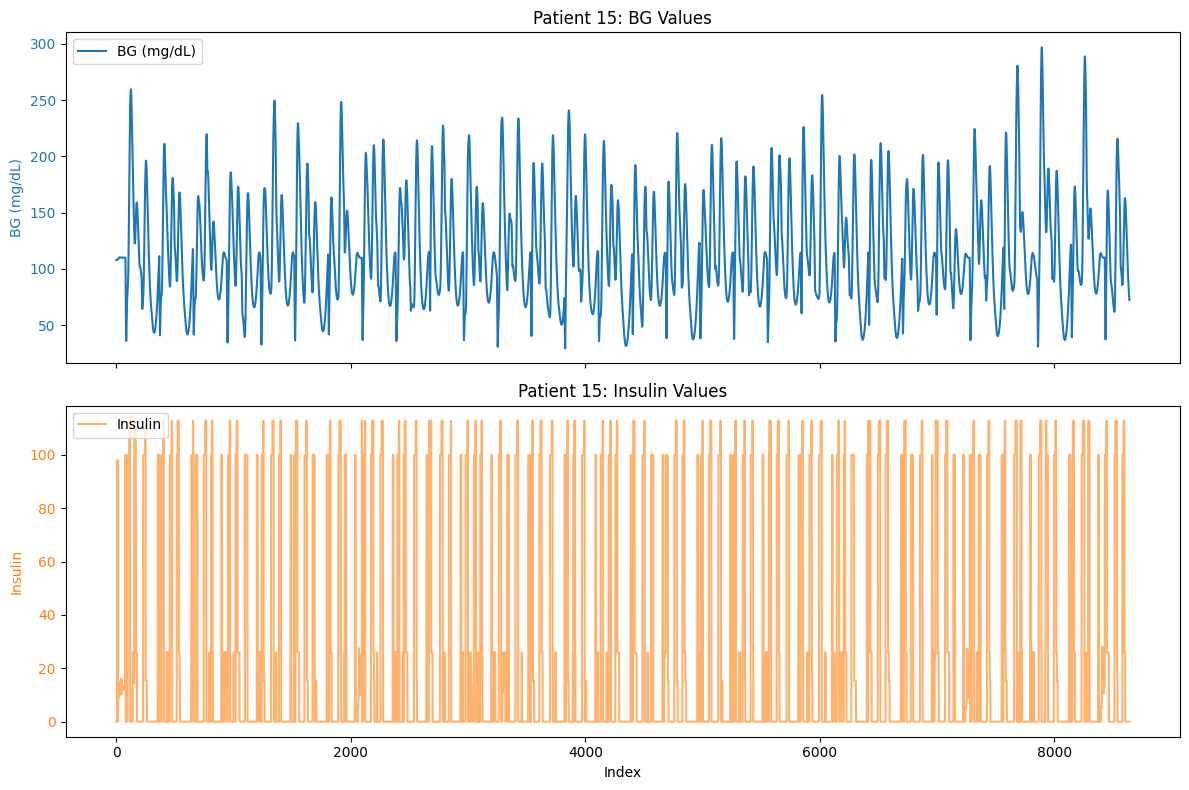

cut time (14, '06:35')
end time (14, '08:35')
-112.58382629418024
sample patient 15
****************************************************************************************************
idx is 18 99.99999893081556
[3.71609895045112e-08, 2.306670410234801e-08, 3.166123008213617e-08, 1.212251419246968e-07, 1.2454802913453022e-06, 99.99999893081556, 99.9999994522346, 99.99999990432904, 99.999999911454, 99.99999657797196]
cut time (14, '07:30')
end time (14, '09:30')
-55.192335387980435
****************************************************************************************************
idx is 26 107.6735726138268
[18.150921621901333, 18.150921618409924, 18.15092161616053, 18.15092149707536, 18.150922171839696, 107.6735726138268, 107.67357249065816, 107.67357253222391, 107.67357253084478, 107.67357250155622]
cut time (14, '08:10')
end time (14, '10:10')
-215.94232221834892
****************************************************************************************************
idx is 7 81.5037632

In [22]:

# transpose the dataframe
!pip install matplotlib
import pandas as pd
import json
import random
import numpy as np
import matplotlib.pyplot as plt
def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

insulin_usage_count = 0

sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_19.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        cut_idx = 13 * 288 + 72
        
        insulin_values = df[i].to_list()
        insulin_values_cut = insulin_values[cut_idx : cut_idx + 288]
        first_insulin_dose = 0
        for idx in range(1, len(insulin_values_cut)):
            if insulin_values_cut[idx] - insulin_values_cut[idx-1] > 80:
                print("idx is", idx, insulin_values_cut[idx])
                print(insulin_values_cut[idx-5:idx+5])
                
                first_insulin_dose = insulin_values_cut[idx]
                insulin_usage_count += 1
                break
        
        if i == sample_patient:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

            ax1.plot(bg_values, color='tab:blue', label='BG (mg/dL)')
            ax1.set_ylabel('BG (mg/dL)', color='tab:blue')
            ax1.tick_params(axis='y', labelcolor='tab:blue')
            ax1.legend(loc='upper left')
            ax1.set_title(f'Patient {i}: BG Values')

            ax2.plot(insulin_values, color='tab:orange', label='Insulin', alpha=0.6)
            ax2.set_xlabel('Index')
            ax2.set_ylabel('Insulin', color='tab:orange')
            ax2.tick_params(axis='y', labelcolor='tab:orange')
            ax2.legend(loc='upper left')
            ax2.set_title(f'Patient {i}: Insulin Values')

            plt.tight_layout()
            plt.show()
        
        cut_idx = cut_idx + idx 
        end_idx = cut_idx + 24 #2 hour
        cut_time = bg_time[cut_idx]

        print("cut time", format_time_info(cut_time))
        print("end time", format_time_info(bg_time[end_idx]))
        bg_start = data['bg_mgdl'][cut_idx]
        bg_end = data['bg_mgdl'][end_idx]

        ans = bg_start - bg_end
        print(ans)
        
        running_events = []
        cycling_events = []
        carb_events = []

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)
                    
        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}   

        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_glucose_drop'
        qa['question_id'] = 'pm_19'
        qa['question_text'] = 'if i take insulin now, how much will my blood glucose come down in the next 2 hours?'
        qa['answer_generation_rule'] = "Assume that insulin will start working immediately and predict the blood glucose level in the next 2 hours."
        qa['answer_instruction'] = "Return a float value of how much the blood glucose level will come down in the next 2 hours. if you think it will increase , then return a negative value."
        qa['answer_type'] = "float"
        qa['metric'] =  'MAE'
        random_value = random.randint(13,65)
        qa['example_answer'] = ans - (random_value/100 * ans)
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx+1]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx+1]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != ans , "Example answer and original answer are the same"
        assert first_insulin_dose ==  output_json['input_context']['insulin_events'][-1]
        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/18.txt", "w") as f:
                f.write(prompt)
        
        h.write(json.dumps(output_json) + "\n")
        print("*" * 100)


### 22. How many hours of stable glucose can I expect overnight?

In [23]:

# transpose the dataframe
import pandas as pd
import json
import random
import numpy as np

def format_time_info(mins):
    mins = float(mins)
    day = int(mins // 1440) + 1  # ← day 1 to 14, no weekly reset
    time_of_day = mins % 1440
    hours = int(time_of_day // 60)
    minutes = int(time_of_day % 60)
    time_str = f"{hours:02d}:{minutes:02d}" 
    return day, time_str

df = pd.read_csv("insulin_input_normal.csv")
df = df.T
i = 0

insulin_usage_count = 0

sample_patient = random.randint(0,20)
with open('./questions/questions_and_answers_20.jsonl', 'w') as h:
    for i in range(0,20):
        file_path = f"/home/srini/time_series/py-mgipsim/SimulationData/normal_day/normal_day_{i}_simulation_data.jsonl"
        with open(file_path, "r") as f:
            data = json.load(f)

        bg_values = data['bg_mgdl']
        bg_time = [t * 5 for t in range(len(bg_values))]

        cut_idx = 13 * 288
        cut_time = bg_time[cut_idx]
        end_idx = int(cut_idx + (288 / 24) * 6)
        test_bg_values = data['bg_mgdl'][cut_idx:end_idx+1]

        bg_split = np.array_split(test_bg_values, 6)
        hr_count = 0
        for spl in bg_split:
            for val in spl:
                if val < 70 or val > 180:
                    hr_count += 1
                    break
        ans = 6 - hr_count
        print(ans)
        
        running_events = []
        cycling_events = []
        carb_events = []

        for ex in data['exercise_events']:
            if ex['exercise_type'] == 'running':
                if ex['time'] < cut_time: 
                    running_events.append(ex)
            elif ex['exercise_type'] == 'cycling':
                if ex['time'] < cut_time: 
                    cycling_events.append(ex)
                    
        for carb in data['carb_events']:
            if carb['time'] < cut_time:
                carb_events.append(carb)

        output_json = {}
        output_json['patient_id'] = 'Patient_'+str(i)
        output_json['input_context'] = {}   

        qa = {}
        qa['patient_id'] = 'Patient_'+str(i)
        qa['function_name'] = 'predict_glucose_drop'
        qa['question_id'] = 'pm_20'
        qa['question_text'] = 'How many hours of stable glucose levels can I expect overnight? (12AM-6AM)'
        qa['answer_generation_rule'] = "Based on the data, predict the number of hours during the 12AM–6AM window when blood glucose will stay within a stable range (70-180 mg/dL). Return an integer value of number of hours where the blood glucose level is stable."
        qa['answer_instruction'] = "Return a int value of how many hours of stable glucose can I expect overnight. (12AM-6AM)"
        qa['answer_type'] = "int"
        qa['metric'] =  'MAE'
        random_value = random.randint(13,65)
        sample_val = [i for i in range(0,7) if i != ans][0]
        qa['example_answer'] = sample_val
        qa['answer'] = ans
        qa['answer_instruction'] = qa['answer_generation_rule']
        output_json['input_context']['running_events'] = running_events
        output_json['input_context']['cycling_events'] = cycling_events
        output_json['input_context']['carb_events'] = carb_events
        output_json['input_context']['insulin_events'] = df[i].to_list()[:cut_idx]
        output_json['input_context']['bg_mgdl'] = data['bg_mgdl'][0:cut_idx]
        output_json['qa_pairs'] = []
        output_json['qa_pairs'].append(qa)

        assert qa['example_answer'] != ans , "Example answer and original answer are the same"

        if i == sample_patient:
            print("sample patient", i)
            prompt = return_prompt(output_json)
            with open("./prompts/prediction/19.txt", "w") as f:
                f.write(prompt)
        
        h.write(json.dumps(output_json) + "\n")

1
2
0
0
6
6
6
4
2
6
1
6
0
3
6
2
1
1
6
6
sample patient 19


#### Combine all

In [24]:
final_output = {}

In [25]:
import json

final_output = {}
c = 0
with open("/home/srini/time_series/py-mgipsim/questions/combined_prediction.jsonl" , "w") as g:
    for i in range(0, 21):
        try:
            with open(f"/home/srini/time_series/py-mgipsim/questions/questions_and_answers_{i}.jsonl"  , "r") as f:
                for line in f:
                    data = json.loads(line)
                    g.write(line)
                c += 1
        except Exception as e:
            print(e)
            pass
        

[Errno 2] No such file or directory: '/home/srini/time_series/py-mgipsim/questions/questions_and_answers_16.jsonl'


### Check

In [26]:
import json
dic = {}
with open("/home/srini/time_series/py-mgipsim/questions/combined_prediction.jsonl" , "r") as f:
    for line in f:
        data = json.loads(line)
        question = data['qa_pairs'][0]['question_text']
        dic[question] = 1


In [27]:
dic

{'Predict during what time of the day will my blood glucose level be highest?': 1,
 'Predict what my blood glucose level will be in 30 minutes?': 1,
 'How much insulin will I consume next monday?': 1,
 'Will having a late night snack now push my sugar to higher limits (>180mg/dL)?': 1,
 'what percentage of the day tomorrow will I stay in range (70-180) assuming i take my insulin correctly?': 1,
 'Will my running exercise cause me to become hypoglycemic in the next 90 minutes if i start training now where I will run for 30 minutes?': 1,
 'What will the glucose level be 1 hour after my breakfast? (Assume I am going to eat my breakfast right away)': 1,
 'What’s the expected glucose change 15 minutes after a morning run session?': 1,
 'What’s the expected glucose change 1 hour after a evening cycling session?': 1,
 'Which exercise is better for me to bring down blood sugar tomorrow - cycling or running?': 1,
 'Is the patient likely to remain within 70–180 mg/dL for the rest of the day?': 1

In [29]:
len(dic)

20